# Notebook: Playground for testing PySR settings

* Evaluate connection between learned advantage (critic) and actual reward from episodes; compare with termination

## Loading packages

In [26]:
# load packages
import os
import warnings
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt


from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import BaseCallback, CheckpointCallback, EvalCallback
from stable_baselines3.common.vec_env import DummyVecEnv, VecMonitor

while not os.getcwd().endswith("GGSpeciale"):
    os.chdir("..")

os.chdir("code/SPID_code")
from gmDAGGER import train_spid
from PySRWrapper_safe import PySRPolicy

os.chdir("../../Simglucose_suite")

os.getcwd()

'/faststorage/project/GGSpeciale/GGSpeciale/Simglucose_suite'

In [27]:
# get teacher 

rewards = pd.read_csv("./models/open_optuna_optimal/clarke_risk/adult-001/progress/reward_curve.csv")

#rewards = pd.read_csv("./models/closed_hist_optuna_optimal_2/clarke_risk/adult-001/progress/reward_curve.csv")



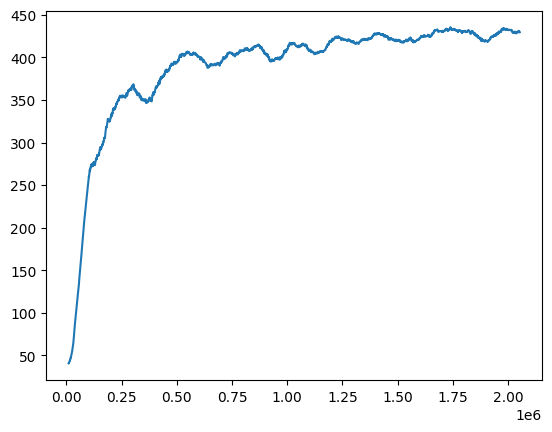

In [28]:

n = 5000

plt.plot(rewards["timestep"][:n], rewards["reward"][:n].rolling(200).mean())

In [ ]:
# progress_sp_path = Path("./distilled_progress/linear_10") # closed
progress_sp_path = Path("./distilled_progress_finer_granularity_2/square_threshold_15") # Open
metrics_log = "clarke_risk/adult-001/distilled_eval/eval_log/metrics_log.csv"
model_path = "clarke_risk/adult-001/best_student_policy.joblib"

progress_summary = pd.DataFrame()

for step_dir in progress_sp_path.iterdir():

    if step_dir.is_dir():

        for run_dir in step_dir.iterdir():
            metrics_path = run_dir / metrics_log
            policy_path = run_dir / model_path

            try:
                results = pd.read_csv(metrics_path)
                results["step"] = int(step_dir.name[5:])
                results["run"] = run_dir.name

                #patient_scores["equation"] = "$" + pysr_policy.policy_list[0].sr.latex() + "$"
                expression = PySRPolicy.load(policy_path).policy_list[0].sr.latex()
                results["expression"] = "$" + expression + "$"

                progress_summary = pd.concat([progress_summary, results])
            except Exception:
                continue

progress_summary.dropna()


#medians = progress_summary.groupby("step")["mean_reward"].transform("median")

# progress_summary_median = (
#     progress_summary[progress_summary["mean_reward"] == medians]
#     .reset_index(drop=True)
# )

Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy loaded
Policy

,eval_index,TBR_II,TBR_I,TIR,TAR_I,TAR_II,total_daily_insulin,average_insulin,TBR_II_episode_mean,TBR_II_episode_std,...,survivors,num_timesteps,mean_reward,std_reward,reward_ti90_95_lower,reward_ti90_95_upper,n_eval_episodes,step,run,expression


In [38]:
progress_summary.dropna(subset="TIR")

,eval_index,TBR_II,TBR_I,TIR,TAR_I,TAR_II,total_daily_insulin,average_insulin,TBR_II_episode_mean,TBR_II_episode_std,...,survivors,num_timesteps,mean_reward,std_reward,reward_ti90_95_lower,reward_ti90_95_upper,n_eval_episodes,step,run,expression
0,0,0.000000,0.000000,24.740125,75.259875,68.399168,0.0,NaN,0.000000,NaN,...,1,NaN,161.655236,12.438252,142.475113,201.319214,100,150000,run_03,$\begin{cases} 1.00 & \text{for}\: x_{2} - x_{...
0,0,0.000000,0.000000,24.740125,75.259875,69.646570,0.0,NaN,0.000000,NaN,...,1,NaN,160.893213,9.867562,142.572968,199.596359,100,180000,run_04,$\left(\begin{cases} 1.00 & \text{for}\: \oper...
0,0,0.000000,0.000000,29.937630,70.062370,61.954262,0.0,NaN,0.000000,NaN,...,1,NaN,199.620117,12.639405,180.544342,242.316788,100,180000,run_00,$\left(\begin{cases} 1.00 & \text{for}\: x_{3}...
0,0,0.000000,0.000000,24.532225,75.467775,68.607069,0.0,NaN,0.000000,NaN,...,1,NaN,161.260685,13.692894,140.956558,205.489929,100,170000,run_03,$x_{1} \cdot 6.04 \left(\begin{cases} 1.00 & \...
0,0,8.108108,24.948025,75.051975,0.000000,0.000000,0.0,NaN,8.108108,NaN,...,1,NaN,235.221689,78.428718,102.042313,395.170197,100,170000,run_02,$\left(\left(x_{3} + \begin{cases} 1.00 & \tex...
0,0,0.000000,13.929314,25.571726,60.498960,47.609148,0.0,NaN,0.000000,NaN,...,1,NaN,194.526581,42.718100,71.583786,249.331924,100,190000,run_00,$\begin{cases} 1.00 & \text{for}\: x_{3} + 0.3...


In [39]:
print(progress_summary.set_index(["step", "run"]).sort_index()[["TIR", "mean_reward", "expression", "critical_failure_rate"]].to_latex())

\begin{tabular}{llrrlr}
\toprule
 &  & TIR & mean_reward & expression & critical_failure_rate \\
step & run &  &  &  &  \\
\midrule
\multirow[t]{3}{*}{10000} & run_00 & NaN & 44.260776 & $0.808 + x_{5} \left(-0.190\right)$ & 100.000000 \\
 & run_03 & NaN & 47.384124 & $1.59 - \begin{cases} 1.00 & \text{for}\: x_{5} > -0.589 \\0.0 & \text{otherwise} \end{cases}$ & 100.000000 \\
 & run_04 & NaN & 45.492328 & $0.874 - \left(x_{2} + x_{5}\right) 0.230$ & 100.000000 \\
\cline{1-6}
\multirow[t]{5}{*}{20000} & run_00 & NaN & 49.164535 & $0.827 + \left(x_{4} + x_{5}\right) \left(-0.395\right)$ & 100.000000 \\
 & run_01 & NaN & 52.396577 & $0.761 - x_{4}$ & 100.000000 \\
 & run_02 & NaN & 50.651756 & $\begin{cases} 1.00 & \text{for}\: x_{4} < -0.461 \\0.0 & \text{otherwise} \end{cases} - -0.498$ & 100.000000 \\
 & run_03 & NaN & 52.600117 & $0.762 - x_{4}$ & 100.000000 \\
 & run_04 & NaN & 49.936585 & $0.840 - x_{4}$ & 100.000000 \\
\cline{1-6}
\multirow[t]{5}{*}{30000} & run_00 & NaN & 52.6630

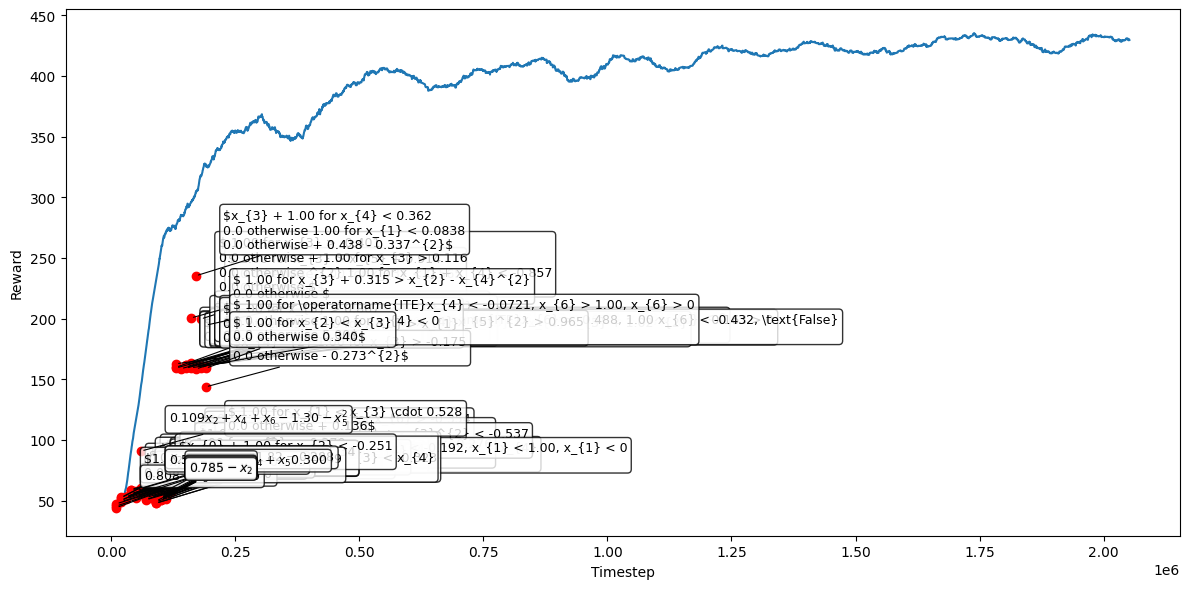

In [41]:
plot_df = progress_summary
import re
import matplotlib.pyplot as plt

plt.rcParams["text.usetex"] = False


def matplotlib_safe_expr(expr):
    expr = str(expr)

    # Remove outer delimiters
    expr = expr.replace(r"\left(", "")
    expr = expr.replace(r"\right)", "")

    # Remove unsupported environments
    expr = expr.replace(r"\begin{cases}", "")
    expr = expr.replace(r"\end{cases}", "")
    expr = expr.replace(r"\begin{matrix}", "")
    expr = expr.replace(r"\end{matrix}", "")

    # Make text commands plain
    expr = expr.replace(r"\text{for}\:", " for ")
    expr = expr.replace(r"\text{for}", " for ")
    expr = expr.replace(r"\mathrm{for}\ ", " for ")
    expr = expr.replace(r"\mathrm{otherwise}", " otherwise ")
    expr = expr.replace(r"\text{otherwise}", " otherwise ")

    # Split case rows
    parts = expr.split(r"\\")

    cleaned_parts = []
    for part in parts:
        part = part.replace("&", " ")
        part = re.sub(r"\s+", " ", part).strip()
        cleaned_parts.append(part)

    # Return as normal text, not mathtext
    return "\n".join(cleaned_parts)

n = 5000

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    rewards["timestep"][:n],
    rewards["reward"][:n].rolling(200).mean()
)

ax.scatter(
    plot_df["step"],
    plot_df["mean_reward"],
    color="red",
    zorder=3
)

for _, row in plot_df.iterrows():
    ax.annotate(
        matplotlib_safe_expr(row["expression"]),
        xy=(row["step"], row["mean_reward"]),
        xytext=(20, 20),
        textcoords="offset points",
        bbox=dict(
            boxstyle="round,pad=0.3",
            fc="white",
            ec="black",
            alpha=0.8
        ),
        arrowprops=dict(
            arrowstyle="-",
            color="black",
            lw=0.8
        ),
        fontsize=9
    )

ax.set_xlabel("Timestep")
ax.set_ylabel("Reward")
plt.tight_layout()
plt.show()